In [1]:
import os
import geopandas as gpd
import numpy as np
import rasterio as rio
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
from rasterstats import zonal_stats
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
import matplotlib.pyplot as plt

In [2]:
os.chdir('..')
os.getcwd()

'/Users/rujalshrestha/Projects/mac-migration/gisc-412/nepal-wildfire'

In [3]:
wildfires = gpd.read_file('output/wildfires.gpkg')

In [4]:
wildfires_bardiya_full = wildfires[wildfires['STATE_CODE'] == "NPL.4.1.2_1"]

In [5]:
wildfires_bardiya = wildfires_bardiya_full.drop(columns=[
  'index_right',
  'STATE_CODE',
  'PROVINCE_CODE',
  'PROVINCE_NAME',
  'DISTRICT_CODE',
  'STATE_NAME',
  'LAYER_TYPE',
  'SUBDIVISION_CODE',
  'DISTRICT_NAME'
])

In [6]:
wildfires_bardiya.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,ACQ_DATE,ACQ_TIME,CONFIDENCE,BRIGHT_T31,FRP,datetime,geometry
107,28.3719,81.6756,300.7,2001-01-15,0618,41,288.3,43.4,2001-01-15 06:18:00,POINT (81.6756 28.3719)
108,28.3621,81.7170,301.4,2001-01-15,0618,46,288.5,47.8,2001-01-15 06:18:00,POINT (81.717 28.3621)
109,28.3599,81.7107,304.1,2001-01-15,0618,58,288.8,56.6,2001-01-15 06:18:00,POINT (81.7107 28.3599)
202,28.5021,81.2749,306.8,2001-02-10,0517,62,292.4,8.6,2001-02-10 05:17:00,POINT (81.2749 28.5021)
203,28.5006,81.2889,305.4,2001-02-10,0517,52,294.1,7.2,2001-02-10 05:17:00,POINT (81.2889 28.5006)


In [7]:
nepal_municipalities = gpd.read_file('data/gadm41_NPL.gpkg', layer='ADM_ADM_4')

In [8]:
bardiya_municipalities = nepal_municipalities[nepal_municipalities['GID_3'] == 'NPL.4.1.2_1'][['NAME_4', 'geometry']].reset_index(drop=True)

In [9]:
bardiya_municipalities.head()

,NAME_4,geometry
0,Badalpur,"MULTIPOLYGON (((81.12878 28.44646, 81.13213 28..."
1,Baganaha,"MULTIPOLYGON (((81.35322 28.41987, 81.34365 28..."
2,Baniyabhar,"MULTIPOLYGON (((81.30164 28.36481, 81.30537 28..."
3,Belawa,"MULTIPOLYGON (((81.59071 28.23619, 81.59232 28..."
4,Bhimapur,"MULTIPOLYGON (((81.15041 28.37132, 81.13278 28..."


In [10]:
with rio.open("output/Topography/cop30_bardiya.tif") as src:
    dem = src.read(1).astype(float)
    transform = src.transform
    
xres = transform.a
yres = -transform.e

gy, gx = np.gradient(dem, yres, xres)
slope = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))

aspect = np.degrees(np.arctan2(-gx, gy))
aspect = np.where(aspect < 0, 360 + aspect, aspect)

In [11]:
# Compute mean elevation, slope, aspect per municipality
elev_stats = zonal_stats(bardiya_municipalities, dem, affine=transform, stats=["mean"])
slope_stats = zonal_stats(bardiya_municipalities, slope, affine=transform, stats=["mean"])
aspect_stats = zonal_stats(bardiya_municipalities, aspect, affine=transform, stats=["mean"])

bardiya_municipalities["mean_elev"] = [x["mean"] for x in elev_stats]
bardiya_municipalities["mean_slope"] = [x["mean"] for x in slope_stats]
bardiya_municipalities["mean_aspect"] = [x["mean"] for x in aspect_stats]

/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


In [12]:
bardiya_municipalities.head()

,NAME_4,geometry,mean_elev,mean_slope,mean_aspect
0,Badalpur,"MULTIPOLYGON (((81.12878 28.44646, 81.13213 28...",149.550405,89.918392,192.298721
1,Baganaha,"MULTIPOLYGON (((81.35322 28.41987, 81.34365 28...",172.409699,89.321476,191.434135
2,Baniyabhar,"MULTIPOLYGON (((81.30164 28.36481, 81.30537 28...",173.485520,89.554248,187.456953
3,Belawa,"MULTIPOLYGON (((81.59071 28.23619, 81.59232 28...",369.133084,89.920006,185.877821
4,Bhimapur,"MULTIPOLYGON (((81.15041 28.37132, 81.13278 28...",143.615370,89.862659,190.219705


In [13]:
# Count wildfires per municipality
# NAME_4 = 4th level name (municipality name)
fire_counts = gpd.sjoin(wildfires_bardiya, bardiya_municipalities, how="inner", predicate="within")
fire_counts = fire_counts.groupby("NAME_4").size().reset_index(name="FIRE_COUNT")

bardiya_gwr = bardiya_municipalities.merge(fire_counts, on="NAME_4", how="left")
bardiya_gwr["FIRE_COUNT"] = bardiya_gwr["FIRE_COUNT"].fillna(0)

In [14]:
bardiya_gwr.head()

,NAME_4,geometry,mean_elev,mean_slope,mean_aspect,FIRE_COUNT
0,Badalpur,"MULTIPOLYGON (((81.12878 28.44646, 81.13213 28...",149.550405,89.918392,192.298721,2.0
1,Baganaha,"MULTIPOLYGON (((81.35322 28.41987, 81.34365 28...",172.409699,89.321476,191.434135,23.0
2,Baniyabhar,"MULTIPOLYGON (((81.30164 28.36481, 81.30537 28...",173.485520,89.554248,187.456953,162.0
3,Belawa,"MULTIPOLYGON (((81.59071 28.23619, 81.59232 28...",369.133084,89.920006,185.877821,83.0
4,Bhimapur,"MULTIPOLYGON (((81.15041 28.37132, 81.13278 28...",143.615370,89.862659,190.219705,11.0


In [15]:
bardiya_gwr.to_file('output/Topography/bardiya_topography.gpkg', driver='GPKG')

In [16]:
gwr_data = bardiya_gwr.dropna(subset=["FIRE_COUNT", "mean_elev", "mean_slope", "mean_aspect"]).copy()

# prepare dependent and independent values
y = gwr_data["FIRE_COUNT"].values.reshape((-1, 1))
X = gwr_data[["mean_elev", "mean_slope", "mean_aspect"]].values

# get centroid of each municipality
coords = np.array([(geom.centroid.x, geom.centroid.y) for geom in gwr_data.geometry])

bw = Sel_BW(coords, y, X, multi=False).search(bw_min=2, bw_max=20)
gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()
print(gwr_results.summary())

Model type                                                         Gaussian
Number of observations:                                                  33
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                        5222190.166
Log-likelihood:                                                    -244.362
AIC:                                                                496.723
AICc:                                                               500.946
BIC:                                                            5222088.767
R2:                                                                   0.600
Adj. R2:                                                              0.559

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

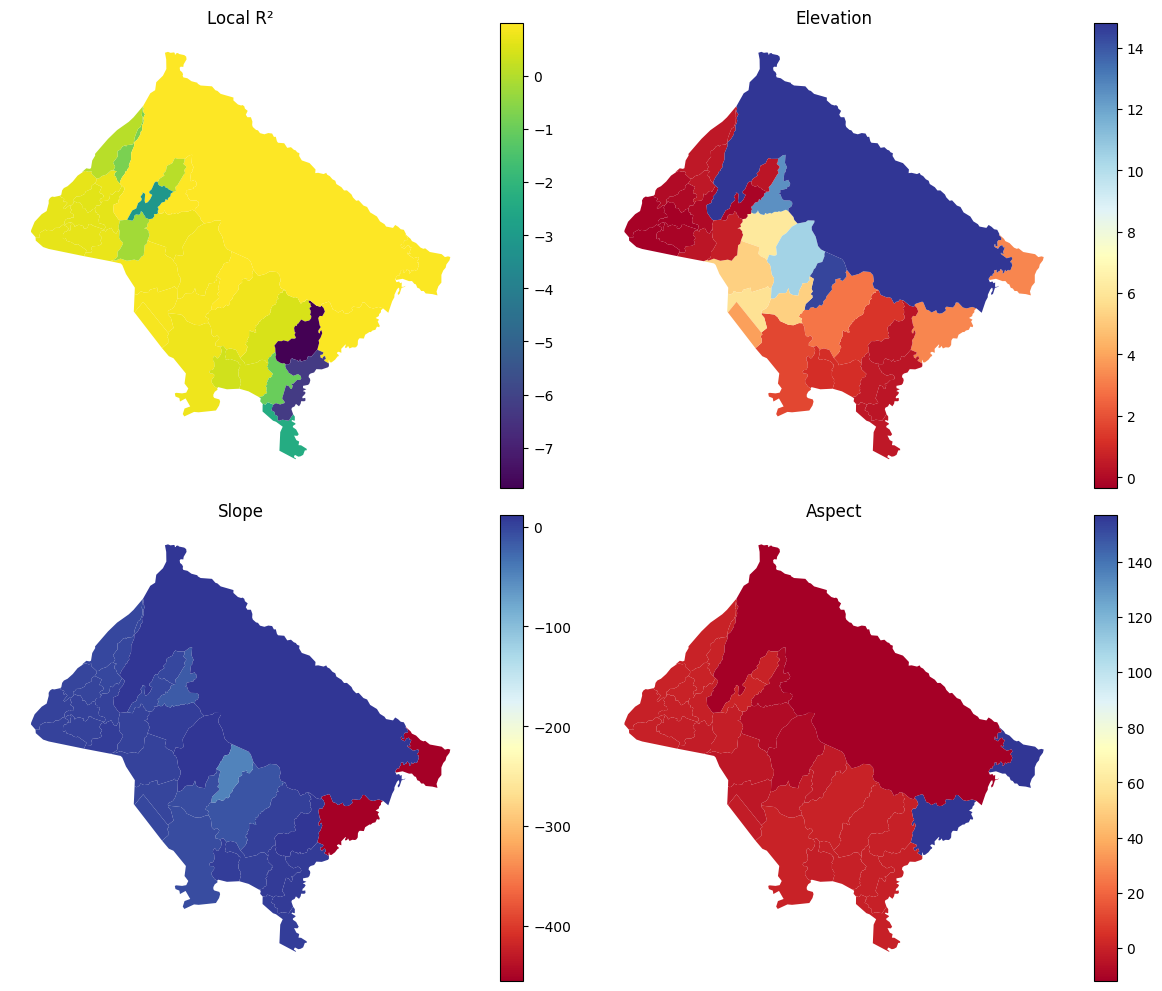

In [17]:
params = gwr_results.params

gwr_data["local_R2"] = gwr_results.localR2
gwr_data["coef_elev"] = params[:, 1]
gwr_data["coef_slope"] = params[:, 2]
gwr_data["coef_aspect"] = params[:, 3]

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

gwr_data.plot(column="local_R2", cmap="viridis", legend=True, ax=ax[0,0])
ax[0,0].set_title("Local R²")
ax[0,0].axis("off")

gwr_data.plot(column="coef_elev", cmap="RdYlBu", legend=True, ax=ax[0,1])
ax[0,1].set_title("Elevation")
ax[0,1].axis("off")

gwr_data.plot(column="coef_slope", cmap="RdYlBu", legend=True, ax=ax[1,0])
ax[1,0].set_title("Slope")
ax[1,0].axis("off")

gwr_data.plot(column="coef_aspect", cmap="RdYlBu", legend=True, ax=ax[1,1])
ax[1,1].set_title("Aspect")
ax[1,1].axis("off")

plt.tight_layout()
plt.show()
